# Rotation

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math

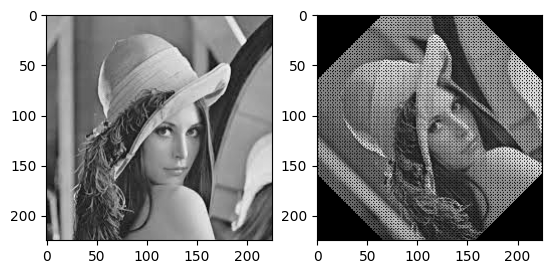

In [17]:
# 시계 반대방향 45 도 회전
# 참고 numpy 는 라디안 씀
src = cv2.imread("images/lenna.jpeg", 0)

H, W = src.shape[:2]

dst = np.zeros((H,W) , dtype = np.uint8)

theta = 45
radian = math.radians(theta)

R_mat = np.array([[np.cos(radian), -np.sin(radian)],
                   [np.sin(radian), np.cos(radian)]])

def ij2xy(pt):
    # 1. switch coordinates
    y,x = pt 


    # 2. change of sign y
    y = -y

    # 3. move
    x = x-W/2
    y = y+H/2

    return (int(x), int(y))

def xy2ij(pt):
    x,y = pt 

    # 1. move
    x = x + W/2
    y = y - H/2

    # 2. change of sign y
    y = -y
    
    # 3. switch coordinates
    h = int(y)
    w = int(x)
    return (h,w)

for h in range(H):
    for w in range(W):
        ij = (h,w)
        xy = ij2xy(ij)

        src_xy = np.array([[xy[0]],
                           [xy[1]]])
        dst_xy = R_mat@src_xy

        
    
        dst_x = dst_xy[0, 0]
        dst_y = dst_xy[1, 0]

        dst_ij = xy2ij((dst_x, dst_y))

    

        if 0 <= dst_ij[0] < H and 0 <= dst_ij[1] < W:
            dst[dst_ij[0], dst_ij[1]] = src[h][w]


plt.subplot(1,2,1)
plt.imshow(src , cmap= 'gray')
plt.subplot(1,2,2)
plt.imshow(dst , cmap = 'gray')
plt.show()
        



역방향 사상 이용해서 빈칸 제거

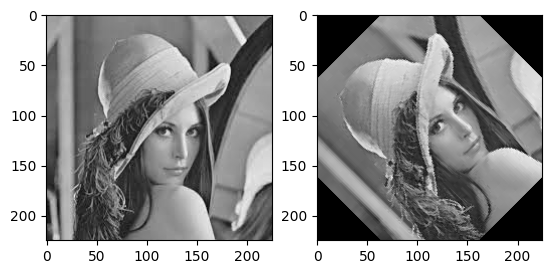

In [18]:
# 시계 반대방향 45 도 회전
# 참고 numpy 는 라디안 씀
src = cv2.imread("images/lenna.jpeg", 0)

H, W = src.shape[:2]

dst = np.zeros((H,W) , dtype = np.uint8)

theta = 45
radian = math.radians(theta)

R_mat = np.array([[np.cos(-radian), -np.sin(-radian)],
                   [np.sin(-radian), np.cos(-radian)]])

for h in range(H):
    for w in range(W):
        ij = (h,w)
        xy = ij2xy(ij)

        dst_xy = np.array([[xy[0]],
                           [xy[1]]])
        src_xy = R_mat@dst_xy

        
    
        src_x = src_xy[0, 0]
        src_y = src_xy[1, 0]

        src_ij = xy2ij((src_x, src_y))

    

        if 0 <= src_ij[0] < H and 0 <= src_ij[1] < W:
            dst[h, w] = src[src_ij[0], src_ij[1]]


plt.subplot(1,2,1)
plt.imshow(src , cmap= 'gray')
plt.subplot(1,2,2)
plt.imshow(dst , cmap = 'gray')
plt.show()
        

